# Détection et classification automatique de maladies des plantes (Tomate - 4 classes)

Ce notebook est une version finale, propre et exécutable de bout en bout.

Il suit le pipeline demandé:
1. Prétraitement des images
2. Segmentation / extraction de contours
3. Extraction de caractéristiques (couleur, texture, forme)
4. Classification Machine Learning
5. Évaluation (accuracy, precision, recall, F1)
6. Extension Deep Learning
7. Comparaison ML vs DL + inférence

Dataset utilisé: sous-ensemble **4 classes tomate** de PlantVillage déjà présent dans ce projet.

## 1) Imports

Toutes les bibliothèques nécessaires sont importées ici.

In [1]:
import json
import math
import random
import warnings
from collections import Counter
from dataclasses import dataclass
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from PIL import Image
from scipy.stats import kurtosis, skew
from skimage.feature import graycomatrix, graycoprops
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.svm import SVC
from torch import nn
from torch.utils.data import DataLoader, Dataset
from torchvision import models, transforms

warnings.filterwarnings("ignore", category=UserWarning)

## 2) Configuration

- `quick_mode=True` pour un run rapide de démonstration.
- Mettre `quick_mode=False` pour exploiter davantage de données/époques.

In [2]:
TARGET_CLASSES = [
    "Tomato___healthy",
    "Tomato___Early_blight",
    "Tomato___Late_blight",
    "Tomato___Leaf_Mold",
]
CLASS_TO_INDEX = {name: idx for idx, name in enumerate(TARGET_CLASSES)}

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]
VALID_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".webp", ".JPG", ".JPEG", ".PNG", ".BMP", ".WEBP"}


@dataclass
class Config:
    quick_mode: bool = True
    image_size: int = 128
    batch_size: int = 64
    num_workers: int = 0
    seed: int = 42

    # DL epochs
    scratch_epochs: int = 3
    transfer_head_epochs: int = 2
    transfer_finetune_epochs: int = 2
    early_stopping_patience: int = 3

    # Runtime controls
    max_train_per_class: int | None = None
    max_val_per_class: int | None = None
    max_test_per_class: int | None = None


def resolve_project_root() -> Path:
    candidates = [Path.cwd(), Path.cwd().parent]
    for c in candidates:
        if (c / "prepared_tomato_data").exists():
            return c.resolve()
    return Path.cwd().resolve()


cfg = Config()
if cfg.quick_mode:
    cfg.scratch_epochs = 1
    cfg.transfer_head_epochs = 1
    cfg.transfer_finetune_epochs = 1
    cfg.max_train_per_class = 250
    cfg.max_val_per_class = 80
    cfg.max_test_per_class = 100

PROJECT_ROOT = resolve_project_root()
DATA_ROOT = (PROJECT_ROOT / "prepared_tomato_data").resolve()
OUTPUT_DIR = (PROJECT_ROOT / "artifacts_notebook").resolve()
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("DATA_ROOT   :", DATA_ROOT)
print("OUTPUT_DIR  :", OUTPUT_DIR)
print(cfg)

PROJECT_ROOT: C:\plant-desease-igl
DATA_ROOT   : C:\plant-desease-igl\prepared_tomato_data
OUTPUT_DIR  : C:\plant-desease-igl\artifacts_notebook
Config(quick_mode=True, image_size=128, batch_size=64, num_workers=0, seed=42, scratch_epochs=1, transfer_head_epochs=1, transfer_finetune_epochs=1, early_stopping_patience=3, max_train_per_class=250, max_val_per_class=80, max_test_per_class=100)


## 3) Reproductibilité

Fixer les seeds évite des variations trop fortes entre les exécutions.

In [3]:
def set_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


set_seed(cfg.seed)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cpu


## 4) Chargement du dataset

Structure attendue:
- `prepared_tomato_data/train/<class_name>/*`
- `prepared_tomato_data/val/<class_name>/*`
- `prepared_tomato_data/test/<class_name>/*`

In [4]:
@dataclass
class Record:
    path: Path
    class_name: str
    split: str


def list_images(folder: Path) -> list[Path]:
    return sorted([p for p in folder.iterdir() if p.is_file() and p.suffix in VALID_EXTENSIONS])


def sample_class_records(paths: list[Path], max_items: int | None, seed: int) -> list[Path]:
    if max_items is None or len(paths) <= max_items:
        return paths
    rng = random.Random(seed)
    return sorted(rng.sample(paths, max_items))


def load_split(split: str, max_per_class: int | None, seed: int) -> list[Record]:
    split_dir = DATA_ROOT / split
    if not split_dir.exists():
        raise FileNotFoundError(
            f"Dossier manquant: {split_dir}.\n"
            "Vérifie que prepared_tomato_data/train|val|test existe."
        )

    records: list[Record] = []
    for idx, class_name in enumerate(TARGET_CLASSES):
        class_dir = split_dir / class_name
        if not class_dir.exists():
            raise FileNotFoundError(f"Classe manquante: {class_dir}")

        images = list_images(class_dir)
        images = sample_class_records(images, max_per_class, seed + idx)
        records.extend([Record(path=p, class_name=class_name, split=split) for p in images])

    return records


train_records = load_split("train", cfg.max_train_per_class, cfg.seed)
val_records = load_split("val", cfg.max_val_per_class, cfg.seed + 100)
test_records = load_split("test", cfg.max_test_per_class, cfg.seed + 200)


def describe(records: list[Record]) -> dict[str, int]:
    c = Counter(r.class_name for r in records)
    return {k: c[k] for k in TARGET_CLASSES}


print("Train:", describe(train_records))
print("Val  :", describe(val_records))
print("Test :", describe(test_records))
print("Total:", len(train_records), len(val_records), len(test_records))

Train: {'Tomato___healthy': 250, 'Tomato___Early_blight': 250, 'Tomato___Late_blight': 250, 'Tomato___Leaf_Mold': 250}
Val  : {'Tomato___healthy': 80, 'Tomato___Early_blight': 80, 'Tomato___Late_blight': 80, 'Tomato___Leaf_Mold': 80}
Test : {'Tomato___healthy': 100, 'Tomato___Early_blight': 100, 'Tomato___Late_blight': 100, 'Tomato___Leaf_Mold': 100}
Total: 1000 320 400


## 5) Aperçu visuel du dataset

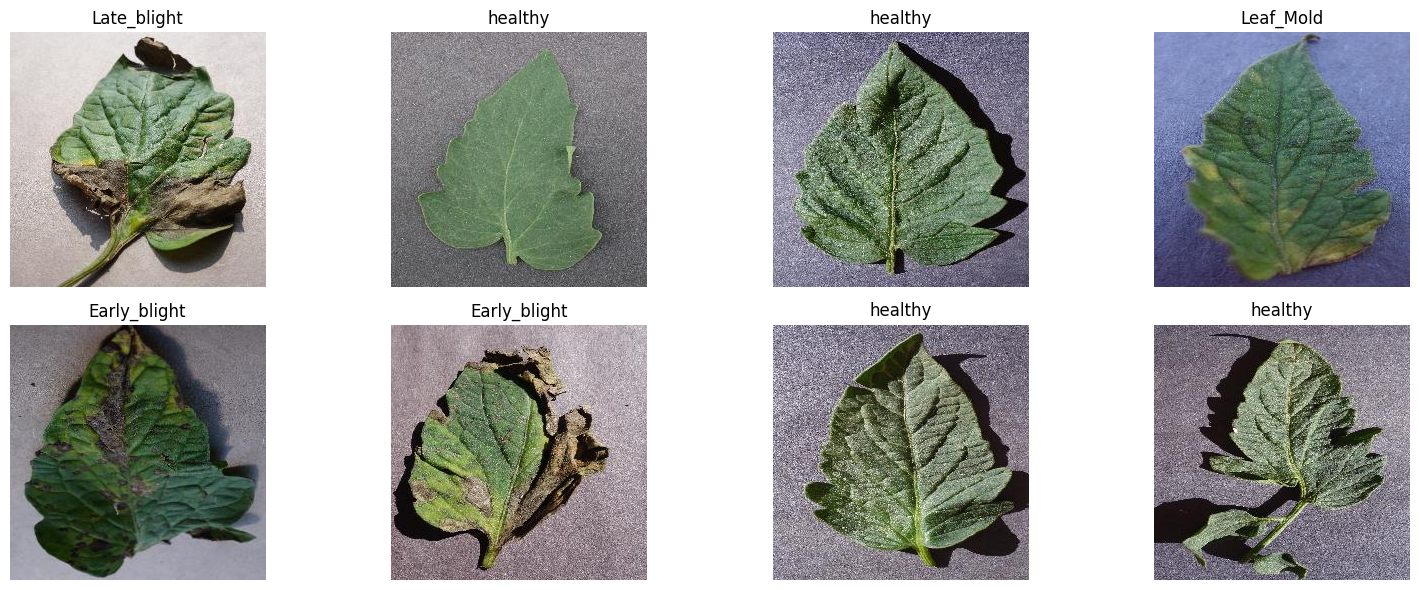

In [5]:
def show_random_images(records: list[Record], n: int = 8) -> None:
    rng = random.Random(cfg.seed)
    chosen = rng.sample(records, min(n, len(records)))
    cols = 4
    rows = math.ceil(len(chosen) / cols)

    fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 3 * rows))
    axes = np.array(axes).reshape(-1)

    for ax, rec in zip(axes, chosen):
        img = Image.open(rec.path).convert("RGB")
        ax.imshow(img)
        ax.set_title(rec.class_name.replace("Tomato___", ""))
        ax.axis("off")

    for ax in axes[len(chosen):]:
        ax.axis("off")

    plt.tight_layout()
    plt.show()


show_random_images(train_records, n=8)

## 6) Prétraitement des images

Prétraitements appliqués (démonstration):
- redimensionnement
- conversion RGB → Grayscale et RGB → HSV
- filtrage gaussien et médian
- analyse d'histogramme

### Justification des choix de pr?traitement

- Le redimensionnement homog?n?ise les entr?es pour rendre l'entra?nement stable et r?duire le co?t de calcul.
- La conversion RGB/HSV/Grayscale permet d'analyser des informations compl?mentaires: couleur, teinte/saturation, texture.
- Les filtres gaussien et m?dian r?duisent le bruit local, ce qui am?liore la robustesse des contours et des features de texture.
- Les histogrammes sont utilis?s comme contr?le qualit? visuel pour v?rifier la s?paration de distributions entre feuilles saines et malades.


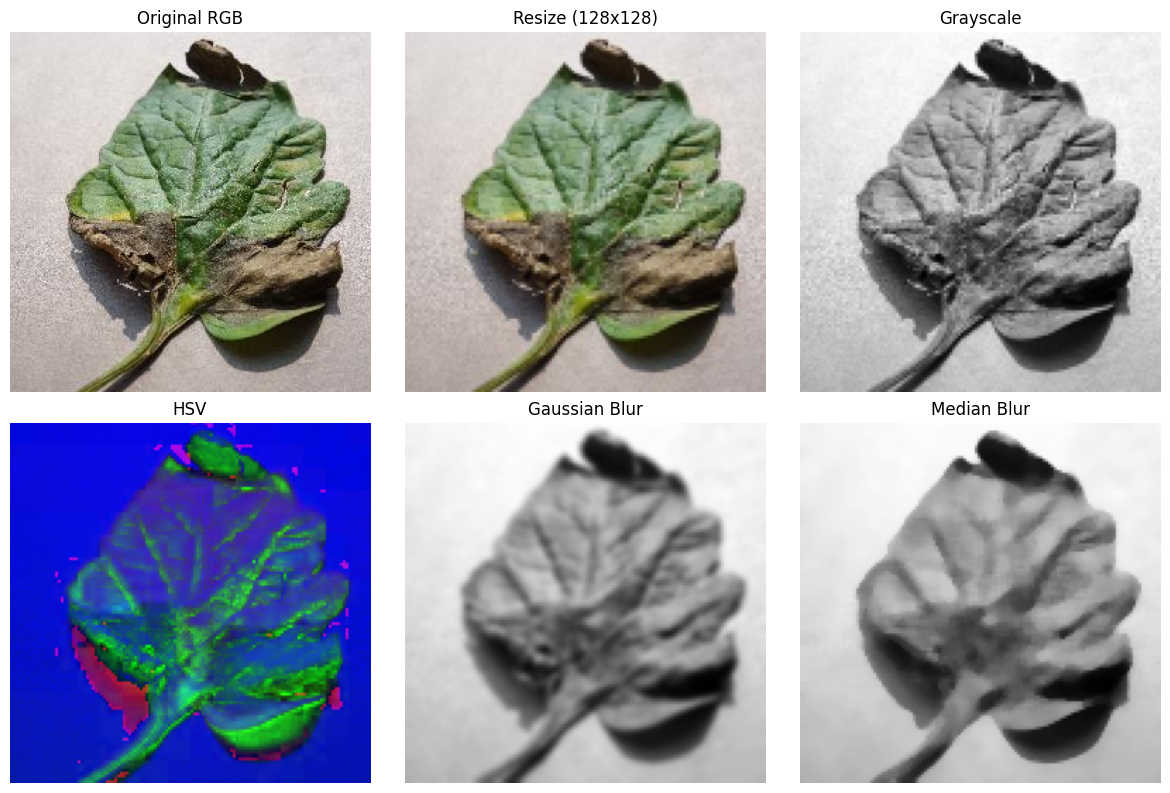

In [6]:
def preprocess_for_demo(image_path: Path, image_size: int = 128):
    img_bgr = cv2.imread(str(image_path))
    if img_bgr is None:
        raise RuntimeError(f"Impossible de lire l'image: {image_path}")

    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    img_resized = cv2.resize(img_rgb, (image_size, image_size))
    img_gray = cv2.cvtColor(img_resized, cv2.COLOR_RGB2GRAY)
    img_hsv = cv2.cvtColor(img_resized, cv2.COLOR_RGB2HSV)
    img_gauss = cv2.GaussianBlur(img_gray, (5, 5), 0)
    img_median = cv2.medianBlur(img_gray, 5)

    return {
        "rgb": img_rgb,
        "resized": img_resized,
        "gray": img_gray,
        "hsv": img_hsv,
        "gauss": img_gauss,
        "median": img_median,
    }


sample_record = random.Random(cfg.seed).choice(train_records)
proc = preprocess_for_demo(sample_record.path, cfg.image_size)

fig, axes = plt.subplots(2, 3, figsize=(12, 8))
axes = axes.ravel()

axes[0].imshow(proc["rgb"])
axes[0].set_title("Original RGB")
axes[1].imshow(proc["resized"])
axes[1].set_title(f"Resize ({cfg.image_size}x{cfg.image_size})")
axes[2].imshow(proc["gray"], cmap="gray")
axes[2].set_title("Grayscale")
axes[3].imshow(proc["hsv"])
axes[3].set_title("HSV")
axes[4].imshow(proc["gauss"], cmap="gray")
axes[4].set_title("Gaussian Blur")
axes[5].imshow(proc["median"], cmap="gray")
axes[5].set_title("Median Blur")

for ax in axes:
    ax.axis("off")

plt.tight_layout()
plt.show()

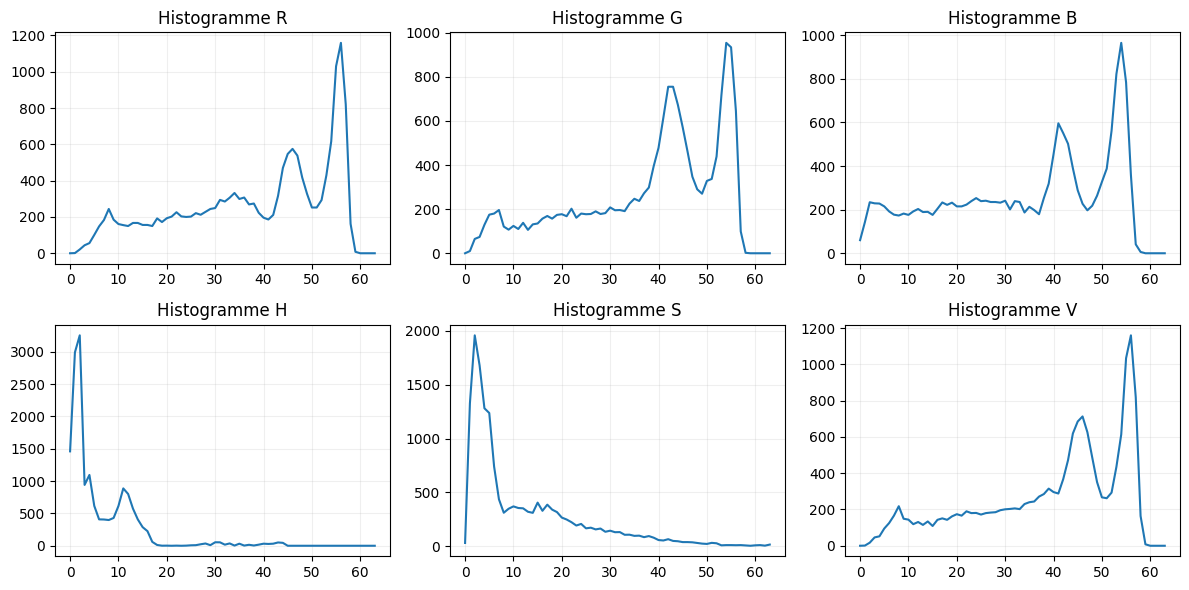

In [7]:
# Histogramme RGB + HSV
img_rgb = proc["resized"]
img_hsv = proc["hsv"]

fig, axes = plt.subplots(2, 3, figsize=(12, 6))
channel_names_rgb = ["R", "G", "B"]
channel_names_hsv = ["H", "S", "V"]

for i, ch in enumerate(channel_names_rgb):
    hist = cv2.calcHist([img_rgb], [i], None, [64], [0, 256]).flatten()
    axes[0, i].plot(hist)
    axes[0, i].set_title(f"Histogramme {ch}")
    axes[0, i].grid(alpha=0.2)

for i, ch in enumerate(channel_names_hsv):
    hist = cv2.calcHist([img_hsv], [i], None, [64], [0, 256]).flatten()
    axes[1, i].plot(hist)
    axes[1, i].set_title(f"Histogramme {ch}")
    axes[1, i].grid(alpha=0.2)

plt.tight_layout()
plt.show()

## 7) Segmentation et extraction de contours

Méthodes comparées:
- contours: Sobel vs Canny
- segmentation: Otsu, HSV, K-means

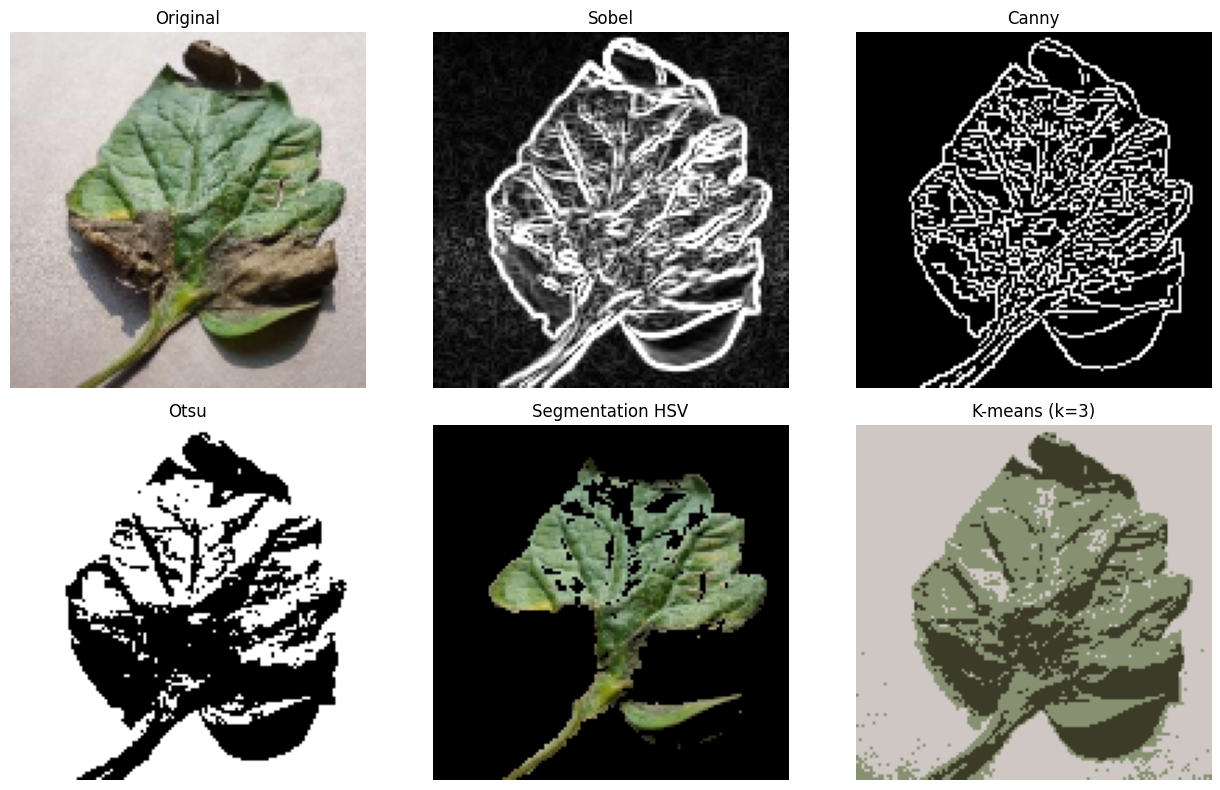

In [8]:
def sobel_edge(gray: np.ndarray) -> np.ndarray:
    sx = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=3)
    sy = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=3)
    mag = cv2.magnitude(sx, sy)
    return np.uint8(np.clip(mag, 0, 255))


def canny_edge(gray: np.ndarray, th1: int = 50, th2: int = 150) -> np.ndarray:
    return cv2.Canny(gray, th1, th2)


def otsu_mask(gray: np.ndarray) -> np.ndarray:
    _, mask = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    return mask


def hsv_leaf_mask(hsv: np.ndarray) -> np.ndarray:
    lower_green = np.array([25, 40, 40], dtype=np.uint8)
    upper_green = np.array([90, 255, 255], dtype=np.uint8)
    return cv2.inRange(hsv, lower_green, upper_green)


def kmeans_segment(rgb: np.ndarray, k: int = 3) -> np.ndarray:
    pixels = rgb.reshape((-1, 3)).astype(np.float32)
    criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 100, 0.2)
    _, labels, centers = cv2.kmeans(pixels, k, None, criteria, 10, cv2.KMEANS_RANDOM_CENTERS)
    centers = np.uint8(centers)
    return centers[labels.flatten()].reshape(rgb.shape)


gray = proc["gray"]
rgb = proc["resized"]
hsv = proc["hsv"]

sob = sobel_edge(gray)
can = canny_edge(gray)
otsu = otsu_mask(gray)
mask_hsv = hsv_leaf_mask(hsv)
seg_hsv = cv2.bitwise_and(rgb, rgb, mask=mask_hsv)
seg_km = kmeans_segment(rgb, k=3)

fig, axes = plt.subplots(2, 3, figsize=(13, 8))
axes = axes.ravel()

axes[0].imshow(rgb)
axes[0].set_title("Original")
axes[1].imshow(sob, cmap="gray")
axes[1].set_title("Sobel")
axes[2].imshow(can, cmap="gray")
axes[2].set_title("Canny")
axes[3].imshow(otsu, cmap="gray")
axes[3].set_title("Otsu")
axes[4].imshow(seg_hsv)
axes[4].set_title("Segmentation HSV")
axes[5].imshow(seg_km)
axes[5].set_title("K-means (k=3)")

for ax in axes:
    ax.axis("off")

plt.tight_layout()
plt.show()

**Comparaison subjective**

- **Sobel**: détecte bien les gradients, mais les contours sont souvent plus épais et plus bruités.
- **Canny**: contours plus fins et plus nets; généralement plus utile pour localiser les lésions.
- **Otsu**: simple et rapide, mais sensible à l'éclairage.
- **HSV**: très efficace pour isoler la feuille si la teinte verte est dominante.
- **K-means**: segmentation plus flexible, parfois meilleure quand les couleurs sont hétérogènes.

## 8) Extraction de caractéristiques (features) pour le ML

Features calculées:
- **Couleur**: histogrammes RGB + HSV
- **Texture**: GLCM (contrast, dissimilarity, homogeneity, energy, correlation)
- **Forme**: surface, périmètre, circularité, etc.

In [9]:
def preprocess_ml_image(path: Path, image_size: int) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    bgr = cv2.imread(str(path))
    if bgr is None:
        raise RuntimeError(f"Image illisible: {path}")
    rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
    rgb = cv2.resize(rgb, (image_size, image_size))
    hsv = cv2.cvtColor(rgb, cv2.COLOR_RGB2HSV)
    gray = cv2.cvtColor(rgb, cv2.COLOR_RGB2GRAY)
    gray = cv2.medianBlur(gray, 5)
    return rgb, hsv, gray


def extract_color_features(rgb: np.ndarray, hsv: np.ndarray) -> list[float]:
    feats = []
    for i in range(3):
        hist = cv2.calcHist([rgb], [i], None, [32], [0, 256]).flatten()
        hist = hist / (hist.sum() + 1e-8)
        feats.extend(hist.tolist())
    for i in range(3):
        hist = cv2.calcHist([hsv], [i], None, [32], [0, 256]).flatten()
        hist = hist / (hist.sum() + 1e-8)
        feats.extend(hist.tolist())
    return feats  # 192


def extract_texture_features(gray: np.ndarray) -> list[float]:
    # Quantification à 64 niveaux pour réduire le coût
    q = (gray // 4).astype(np.uint8)
    glcm = graycomatrix(
        q,
        distances=[1],
        angles=[0, np.pi / 4, np.pi / 2],
        levels=64,
        symmetric=True,
        normed=True,
    )
    feats = []
    for prop in ["contrast", "dissimilarity", "homogeneity", "energy", "correlation"]:
        vals = graycoprops(glcm, prop).flatten()
        feats.extend(vals.tolist())
    return feats  # 15


def extract_shape_features(rgb: np.ndarray, hsv: np.ndarray, gray: np.ndarray) -> list[float]:
    v = hsv[:, :, 2]
    _, mask = cv2.threshold(v, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)

    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        return [0.0] * 9

    cnt = max(contours, key=cv2.contourArea)
    area = float(cv2.contourArea(cnt))
    perimeter = float(cv2.arcLength(cnt, True))
    circularity = float((4.0 * np.pi * area) / ((perimeter ** 2) + 1e-8))

    x, y, w, h = cv2.boundingRect(cnt)
    aspect_ratio = float(w) / (h + 1e-8)
    extent = float(area) / ((w * h) + 1e-8)

    hull = cv2.convexHull(cnt)
    hull_area = float(cv2.contourArea(hull))
    solidity = float(area) / (hull_area + 1e-8)

    # proportion de pixels non verts dans la feuille (proxy lésion)
    green_mask = hsv_leaf_mask(hsv)
    leaf_pixels = mask > 0
    diseased_pixels = (green_mask == 0) & leaf_pixels
    disease_ratio = float(diseased_pixels.sum() / (leaf_pixels.sum() + 1e-8))

    # intensité: moyenne + skewness + kurtosis sur zone feuille
    vals = gray[leaf_pixels].astype(np.float32)
    mean_intensity = float(vals.mean()) if vals.size else 0.0
    skew_intensity = float(skew(vals)) if vals.size > 2 else 0.0
    kurt_intensity = float(kurtosis(vals)) if vals.size > 3 else 0.0

    return [
        area,
        perimeter,
        circularity,
        aspect_ratio,
        extent,
        solidity,
        disease_ratio,
        mean_intensity,
        skew_intensity + kurt_intensity,
    ]


def extract_features_from_path(path: Path, image_size: int) -> np.ndarray:
    rgb, hsv, gray = preprocess_ml_image(path, image_size)
    feats = []
    feats.extend(extract_color_features(rgb, hsv))
    feats.extend(extract_texture_features(gray))
    feats.extend(extract_shape_features(rgb, hsv, gray))
    return np.array(feats, dtype=np.float32)


example_feats = extract_features_from_path(sample_record.path, cfg.image_size)
print("Nombre de features:", example_feats.shape[0])
print("Extrait (10 premières):", example_feats[:10])

Nombre de features: 216
Extrait (10 premières): [6.1035156e-05 3.9672852e-03 9.5825195e-03 2.0202637e-02 2.6184082e-02
 1.9287109e-02 1.9348145e-02 1.9714355e-02 1.8676758e-02 2.2216797e-02]


In [10]:
def build_feature_matrix(records: list[Record], image_size: int, verbose: bool = True):
    X, y, paths = [], [], []
    for idx, rec in enumerate(records, start=1):
        X.append(extract_features_from_path(rec.path, image_size))
        y.append(rec.class_name)
        paths.append(str(rec.path))
        if verbose and (idx % 200 == 0 or idx == len(records)):
            print(f"{idx}/{len(records)}")

    X = np.vstack(X)
    y = np.array(y)
    return X, y, paths


print("Extraction features train...")
X_train_ml, y_train_ml, train_paths_ml = build_feature_matrix(train_records, cfg.image_size, verbose=True)
print("Extraction features val...")
X_val_ml, y_val_ml, val_paths_ml = build_feature_matrix(val_records, cfg.image_size, verbose=True)
print("Extraction features test...")
X_test_ml, y_test_ml, test_paths_ml = build_feature_matrix(test_records, cfg.image_size, verbose=True)

print("Shapes:", X_train_ml.shape, X_val_ml.shape, X_test_ml.shape)

Extraction features train...


200/1000


400/1000


600/1000


800/1000


1000/1000
Extraction features val...


200/320


320/320
Extraction features test...


200/400


400/400
Shapes: (1000, 216) (320, 216) (400, 216)


## 9) Classification Machine Learning

Modèles inspirés du notebook exemple:
- Random Forest
- SVM (RBF)
- KNN

### Justification des mod?les ML

- **Random Forest**: bon point de d?part pour des features h?t?rog?nes (couleur + texture + forme), peu sensible au scaling.
- **SVM RBF**: performant sur des fronti?res non lin?aires, souvent fort en vision classique quand les features sont bien construites.
- **KNN**: baseline simple et interpr?table pour comparer un mod?le ? voisinage.

La s?lection du meilleur mod?le est faite sur la validation (score `f1_weighted`) pour ?viter un choix biais? par le test.


In [11]:
le = LabelEncoder()
le.fit(TARGET_CLASSES)

y_train_enc = le.transform(y_train_ml)
y_val_enc = le.transform(y_val_ml)
y_test_enc = le.transform(y_test_ml)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_ml)
X_val_scaled = scaler.transform(X_val_ml)
X_test_scaled = scaler.transform(X_test_ml)

models_ml = {
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=cfg.seed, n_jobs=-1),
    "SVM": SVC(kernel="rbf", C=10, gamma="scale", random_state=cfg.seed),
    "KNN": KNeighborsClassifier(n_neighbors=5, n_jobs=-1),
}

ml_val_results = {}
ml_trained = {}

for name, model in models_ml.items():
    print(f"Training {name}...")
    model.fit(X_train_scaled, y_train_enc)
    ml_trained[name] = model

    pred_val = model.predict(X_val_scaled)
    ml_val_results[name] = {
        "accuracy": accuracy_score(y_val_enc, pred_val),
        "precision": precision_score(y_val_enc, pred_val, average="weighted", zero_division=0),
        "recall": recall_score(y_val_enc, pred_val, average="weighted", zero_division=0),
        "f1_weighted": f1_score(y_val_enc, pred_val, average="weighted", zero_division=0),
    }

pd.DataFrame(ml_val_results).T.sort_values("f1_weighted", ascending=False)

Training Random Forest...


Training SVM...
Training KNN...


,accuracy,precision,recall,f1_weighted
SVM,0.928125,0.928038,0.928125,0.928064
Random Forest,0.925000,0.925899,0.925000,0.924604
KNN,0.856250,0.857105,0.856250,0.854182


In [12]:
best_ml_name = max(ml_val_results.keys(), key=lambda k: ml_val_results[k]["f1_weighted"])
best_ml = ml_trained[best_ml_name]

print("Meilleur modèle ML (val):", best_ml_name)

pred_test_ml = best_ml.predict(X_test_scaled)
ml_test_metrics = {
    "model": best_ml_name,
    "accuracy": float(accuracy_score(y_test_enc, pred_test_ml)),
    "precision": float(precision_score(y_test_enc, pred_test_ml, average="weighted", zero_division=0)),
    "recall": float(recall_score(y_test_enc, pred_test_ml, average="weighted", zero_division=0)),
    "f1_weighted": float(f1_score(y_test_enc, pred_test_ml, average="weighted", zero_division=0)),
}
print(json.dumps(ml_test_metrics, indent=2))

print("\nClassification report (ML best):")
print(classification_report(y_test_enc, pred_test_ml, target_names=le.classes_, zero_division=0))

Meilleur modèle ML (val): SVM
{
  "model": "SVM",
  "accuracy": 0.95,
  "precision": 0.9505360710717854,
  "recall": 0.95,
  "f1_weighted": 0.9501417515384409
}

Classification report (ML best):
                       precision    recall  f1-score   support

Tomato___Early_blight       0.91      0.95      0.93       100
 Tomato___Late_blight       0.91      0.90      0.90       100
   Tomato___Leaf_Mold       0.98      0.96      0.97       100
     Tomato___healthy       1.00      0.99      0.99       100

             accuracy                           0.95       400
            macro avg       0.95      0.95      0.95       400
         weighted avg       0.95      0.95      0.95       400



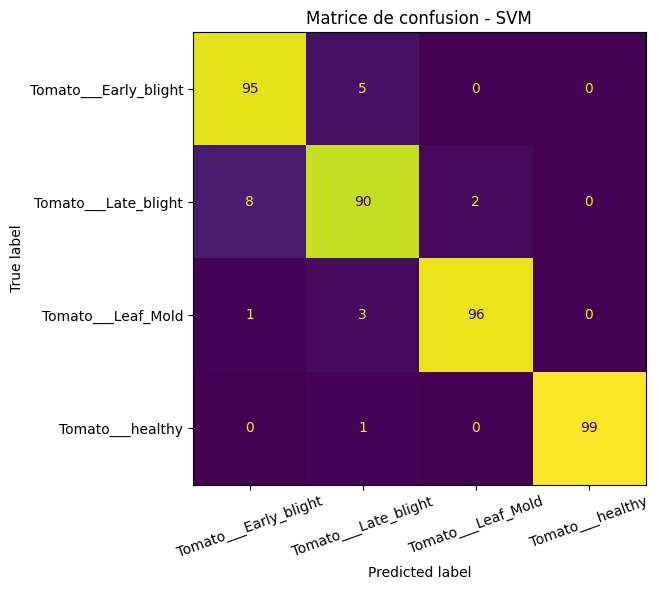

In [13]:
cm_ml = confusion_matrix(y_test_enc, pred_test_ml)
fig, ax = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay(confusion_matrix=cm_ml, display_labels=le.classes_).plot(ax=ax, xticks_rotation=20, colorbar=False)
plt.title(f"Matrice de confusion - {best_ml_name}")
plt.tight_layout()
plt.show()

## 10) Extension Deep Learning

Deux modèles DL comparés:
- CNN from scratch
- MobileNetV3 transfer learning

In [14]:
class TomatoDataset(Dataset):
    def __init__(self, records: list[Record], transform):
        self.records = records
        self.transform = transform

    def __len__(self):
        return len(self.records)

    def __getitem__(self, idx):
        rec = self.records[idx]
        img = Image.open(rec.path).convert("RGB")
        x = self.transform(img)
        y = CLASS_TO_INDEX[rec.class_name]
        return x, y


def make_dl_transforms(image_size: int):
    train_tf = transforms.Compose([
        transforms.RandomResizedCrop(image_size, scale=(0.75, 1.0)),
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(12),
        transforms.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.15),
        transforms.ToTensor(),
        transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    ])

    eval_tf = transforms.Compose([
        transforms.Resize(int(image_size * 1.15)),
        transforms.CenterCrop(image_size),
        transforms.ToTensor(),
        transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    ])
    return train_tf, eval_tf


train_tf, eval_tf = make_dl_transforms(cfg.image_size)

dl_train_ds = TomatoDataset(train_records, train_tf)
dl_val_ds = TomatoDataset(val_records, eval_tf)
dl_test_ds = TomatoDataset(test_records, eval_tf)

train_loader = DataLoader(dl_train_ds, batch_size=cfg.batch_size, shuffle=True, num_workers=cfg.num_workers)
val_loader = DataLoader(dl_val_ds, batch_size=cfg.batch_size, shuffle=False, num_workers=cfg.num_workers)
test_loader = DataLoader(dl_test_ds, batch_size=cfg.batch_size, shuffle=False, num_workers=cfg.num_workers)

print(len(dl_train_ds), len(dl_val_ds), len(dl_test_ds))

1000 320 400


In [15]:
class ScratchCNN(nn.Module):
    def __init__(self, num_classes: int):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(128, 256, 3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool2d((1, 1)),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)


def build_mobilenet_transfer(num_classes: int) -> nn.Module:
    try:
        weights = models.MobileNet_V3_Small_Weights.IMAGENET1K_V1
    except Exception:
        weights = None

    model = models.mobilenet_v3_small(weights=weights)
    for p in model.features.parameters():
        p.requires_grad = False

    model.classifier = nn.Sequential(
        nn.Linear(model.classifier[0].in_features, 256),
        nn.Hardswish(),
        nn.Dropout(0.4),
        nn.Linear(256, num_classes),
    )
    return model


def unfreeze_last_mobilenet_blocks(model: nn.Module) -> None:
    for p in model.features[-3:].parameters():
        p.requires_grad = True


def class_weights(records: list[Record], device: torch.device):
    count = Counter(CLASS_TO_INDEX[r.class_name] for r in records)
    w = [1.0 / count[i] for i in range(len(TARGET_CLASSES))]
    arr = np.array(w, dtype=np.float32)
    arr = arr / arr.sum() * len(TARGET_CLASSES)
    return torch.tensor(arr, dtype=torch.float32, device=device)

In [16]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss, total_correct, total_count = 0.0, 0, 0

    for x, y in loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad(set_to_none=True)
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * x.size(0)
        total_correct += (logits.argmax(1) == y).sum().item()
        total_count += y.size(0)

    return total_loss / total_count, total_correct / total_count


@torch.no_grad()
def evaluate_model(model, loader, criterion, device):
    model.eval()
    total_loss, total_correct, total_count = 0.0, 0, 0
    y_true, y_pred = [], []

    for x, y in loader:
        x, y = x.to(device), y.to(device)
        logits = model(x)
        loss = criterion(logits, y)
        pred = logits.argmax(1)

        total_loss += loss.item() * x.size(0)
        total_correct += (pred == y).sum().item()
        total_count += y.size(0)

        y_true.extend(y.cpu().numpy().tolist())
        y_pred.extend(pred.cpu().numpy().tolist())

    return total_loss / total_count, total_correct / total_count, np.array(y_true), np.array(y_pred)


def fit(model, train_loader, val_loader, criterion, optimizer, scheduler, epochs, patience, device):
    history = []
    best_state = None
    best_val = -1.0
    no_improve = 0

    for epoch in range(1, epochs + 1):
        tr_loss, tr_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
        va_loss, va_acc, _, _ = evaluate_model(model, val_loader, criterion, device)

        history.append({
            "epoch": epoch,
            "train_loss": tr_loss,
            "train_acc": tr_acc,
            "val_loss": va_loss,
            "val_acc": va_acc,
            "lr": optimizer.param_groups[0]["lr"],
        })

        if isinstance(scheduler, torch.optim.lr_scheduler.ReduceLROnPlateau):
            scheduler.step(va_loss)
        elif scheduler is not None:
            scheduler.step()

        print(f"epoch {epoch:02d}/{epochs} - train_acc={tr_acc:.4f} val_acc={va_acc:.4f}")

        if va_acc > best_val:
            best_val = va_acc
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            no_improve = 0
        else:
            no_improve += 1

        if no_improve >= patience:
            print("early stopping")
            break

    if best_state is not None:
        model.load_state_dict(best_state)

    return model, history


def summarize_test_metrics(y_true: np.ndarray, y_pred: np.ndarray) -> dict[str, float]:
    return {
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "precision": float(precision_score(y_true, y_pred, average="weighted", zero_division=0)),
        "recall": float(recall_score(y_true, y_pred, average="weighted", zero_division=0)),
        "f1_weighted": float(f1_score(y_true, y_pred, average="weighted", zero_division=0)),
    }

### 10.1 CNN from scratch

In [17]:
criterion_dl = nn.CrossEntropyLoss(weight=class_weights(train_records, device))

scratch_model = ScratchCNN(num_classes=len(TARGET_CLASSES)).to(device)
opt_scratch = torch.optim.AdamW(scratch_model.parameters(), lr=1e-3, weight_decay=1e-4)
sch_scratch = torch.optim.lr_scheduler.ReduceLROnPlateau(opt_scratch, mode="min", patience=1, factor=0.5)

scratch_model, hist_scratch = fit(
    scratch_model,
    train_loader,
    val_loader,
    criterion_dl,
    opt_scratch,
    sch_scratch,
    cfg.scratch_epochs,
    cfg.early_stopping_patience,
    device,
)

scratch_test_loss, scratch_test_acc, y_true_s, y_pred_s = evaluate_model(scratch_model, test_loader, criterion_dl, device)
metrics_scratch = summarize_test_metrics(y_true_s, y_pred_s)
metrics_scratch["model"] = "CNN Scratch"
metrics_scratch["test_loss"] = float(scratch_test_loss)

print(json.dumps(metrics_scratch, indent=2))

epoch 01/1 - train_acc=0.5870 val_acc=0.3844


{
  "accuracy": 0.345,
  "precision": 0.30192307692307696,
  "recall": 0.345,
  "f1_weighted": 0.2671007758122096,
  "model": "CNN Scratch",
  "test_loss": 1.510378828048706
}


### 10.2 MobileNetV3 (Transfer Learning)

In [18]:
transfer_model = build_mobilenet_transfer(num_classes=len(TARGET_CLASSES)).to(device)
criterion_tf = nn.CrossEntropyLoss(weight=class_weights(train_records, device), label_smoothing=0.05)

# Phase 1: head training
opt_head = torch.optim.AdamW(filter(lambda p: p.requires_grad, transfer_model.parameters()), lr=3e-4, weight_decay=1e-4)
sch_head = torch.optim.lr_scheduler.ReduceLROnPlateau(opt_head, mode="min", patience=1, factor=0.5)
transfer_model, hist_head = fit(
    transfer_model,
    train_loader,
    val_loader,
    criterion_tf,
    opt_head,
    sch_head,
    cfg.transfer_head_epochs,
    cfg.early_stopping_patience,
    device,
)

# Phase 2: fine-tuning last blocks
unfreeze_last_mobilenet_blocks(transfer_model)
opt_ft = torch.optim.AdamW(filter(lambda p: p.requires_grad, transfer_model.parameters()), lr=1e-4, weight_decay=1e-4)
sch_ft = torch.optim.lr_scheduler.ReduceLROnPlateau(opt_ft, mode="min", patience=1, factor=0.5)
transfer_model, hist_ft = fit(
    transfer_model,
    train_loader,
    val_loader,
    criterion_tf,
    opt_ft,
    sch_ft,
    cfg.transfer_finetune_epochs,
    cfg.early_stopping_patience,
    device,
)

hist_transfer = hist_head + [{**h, "epoch": h["epoch"] + len(hist_head)} for h in hist_ft]

transfer_test_loss, transfer_test_acc, y_true_t, y_pred_t = evaluate_model(transfer_model, test_loader, criterion_tf, device)
metrics_transfer = summarize_test_metrics(y_true_t, y_pred_t)
metrics_transfer["model"] = "MobileNetV3 Transfer"
metrics_transfer["test_loss"] = float(transfer_test_loss)

print(json.dumps(metrics_transfer, indent=2))

epoch 01/1 - train_acc=0.4780 val_acc=0.4375


epoch 01/1 - train_acc=0.7050 val_acc=0.5969


{
  "accuracy": 0.5625,
  "precision": 0.7220744138634048,
  "recall": 0.5625,
  "f1_weighted": 0.5221577635915203,
  "model": "MobileNetV3 Transfer",
  "test_loss": 1.1156620979309082
}


### Analyse des courbes d'entra?nement DL

Lecture recommand?e des courbes `train` vs `val`:

- Si `train_acc` augmente mais `val_acc` stagne ou baisse: signe de sur-apprentissage.
- Si `train_acc` et `val_acc` restent faibles: sous-apprentissage (capacit?, epochs ou r?glages insuffisants).
- Si l'?cart `train/val` est mod?r? et les deux progressent: g?n?ralisation correcte.

Dans ce projet, le transfert MobileNetV3 est attendu plus stable que le CNN scratch sur petit jeu de donn?es, gr?ce aux poids pr?-entra?n?s.


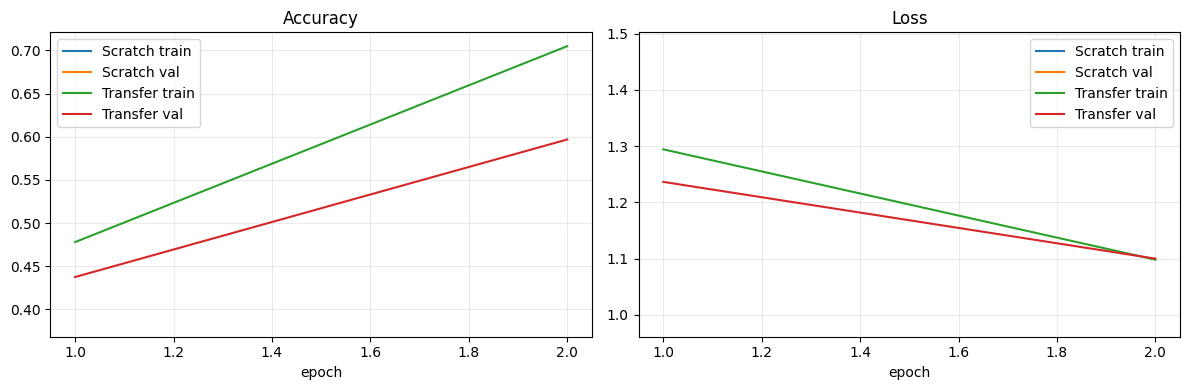

In [19]:
# Courbes d'entraînement DL
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

if hist_scratch:
    hs = pd.DataFrame(hist_scratch)
    axes[0].plot(hs["epoch"], hs["train_acc"], label="Scratch train")
    axes[0].plot(hs["epoch"], hs["val_acc"], label="Scratch val")

if hist_transfer:
    ht = pd.DataFrame(hist_transfer)
    axes[0].plot(ht["epoch"], ht["train_acc"], label="Transfer train")
    axes[0].plot(ht["epoch"], ht["val_acc"], label="Transfer val")

axes[0].set_title("Accuracy")
axes[0].set_xlabel("epoch")
axes[0].grid(alpha=0.25)
axes[0].legend()

if hist_scratch:
    axes[1].plot(hs["epoch"], hs["train_loss"], label="Scratch train")
    axes[1].plot(hs["epoch"], hs["val_loss"], label="Scratch val")

if hist_transfer:
    axes[1].plot(ht["epoch"], ht["train_loss"], label="Transfer train")
    axes[1].plot(ht["epoch"], ht["val_loss"], label="Transfer val")

axes[1].set_title("Loss")
axes[1].set_xlabel("epoch")
axes[1].grid(alpha=0.25)
axes[1].legend()

plt.tight_layout()
plt.show()

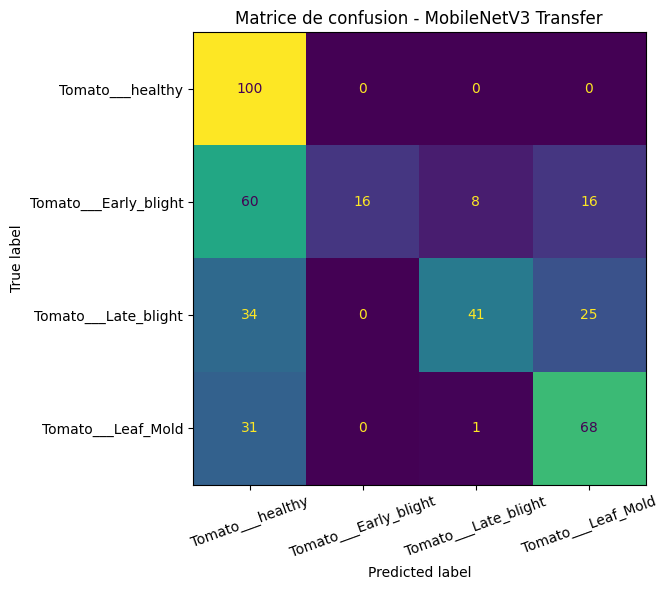

Meilleur modèle DL: MobileNetV3 Transfer
                       precision    recall  f1-score   support

     Tomato___healthy       0.44      1.00      0.62       100
Tomato___Early_blight       1.00      0.16      0.28       100
 Tomato___Late_blight       0.82      0.41      0.55       100
   Tomato___Leaf_Mold       0.62      0.68      0.65       100

             accuracy                           0.56       400
            macro avg       0.72      0.56      0.52       400
         weighted avg       0.72      0.56      0.52       400



In [20]:
# Matrice de confusion pour le meilleur DL
if metrics_transfer["accuracy"] >= metrics_scratch["accuracy"]:
    best_dl_name = "MobileNetV3 Transfer"
    best_dl_y_true, best_dl_y_pred = y_true_t, y_pred_t
    best_dl_model = transfer_model
else:
    best_dl_name = "CNN Scratch"
    best_dl_y_true, best_dl_y_pred = y_true_s, y_pred_s
    best_dl_model = scratch_model

cm_dl = confusion_matrix(best_dl_y_true, best_dl_y_pred)
fig, ax = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay(confusion_matrix=cm_dl, display_labels=TARGET_CLASSES).plot(ax=ax, xticks_rotation=20, colorbar=False)
plt.title(f"Matrice de confusion - {best_dl_name}")
plt.tight_layout()
plt.show()

print("Meilleur modèle DL:", best_dl_name)
print(classification_report(best_dl_y_true, best_dl_y_pred, target_names=TARGET_CLASSES, zero_division=0))

## 11) Comparaison globale ML vs DL

In [21]:
comparison_rows = [
    {
        "family": "ML",
        "model": ml_test_metrics["model"],
        "accuracy": ml_test_metrics["accuracy"],
        "precision": ml_test_metrics["precision"],
        "recall": ml_test_metrics["recall"],
        "f1_weighted": ml_test_metrics["f1_weighted"],
    },
    {
        "family": "DL",
        "model": metrics_scratch["model"],
        "accuracy": metrics_scratch["accuracy"],
        "precision": metrics_scratch["precision"],
        "recall": metrics_scratch["recall"],
        "f1_weighted": metrics_scratch["f1_weighted"],
    },
    {
        "family": "DL",
        "model": metrics_transfer["model"],
        "accuracy": metrics_transfer["accuracy"],
        "precision": metrics_transfer["precision"],
        "recall": metrics_transfer["recall"],
        "f1_weighted": metrics_transfer["f1_weighted"],
    },
]

comparison_df = pd.DataFrame(comparison_rows).sort_values("f1_weighted", ascending=False)
comparison_df

,family,model,accuracy,precision,recall,f1_weighted
0,ML,SVM,0.9500,0.950536,0.9500,0.950142
2,DL,MobileNetV3 Transfer,0.5625,0.722074,0.5625,0.522158
1,DL,CNN Scratch,0.3450,0.301923,0.3450,0.267101


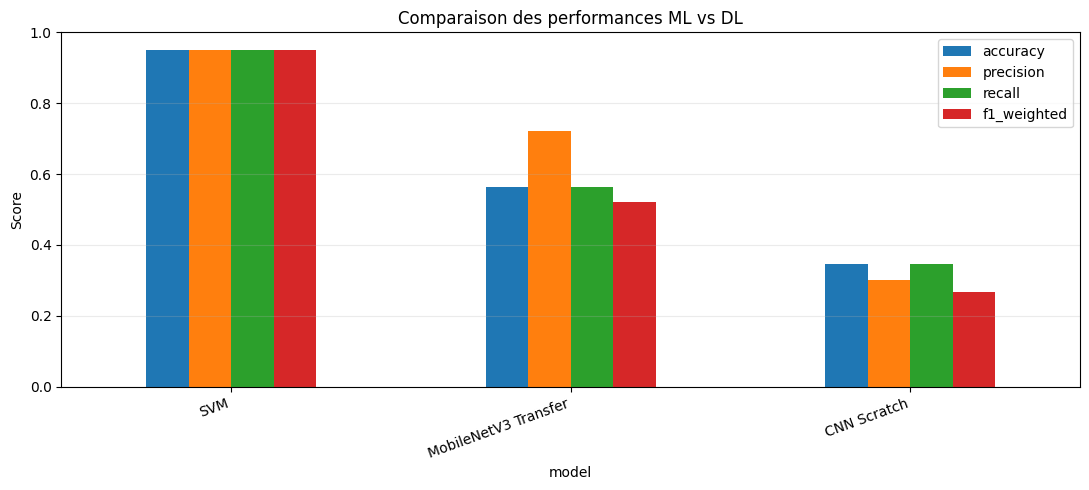

In [22]:
plot_df = comparison_df.set_index("model")[["accuracy", "precision", "recall", "f1_weighted"]]
ax = plot_df.plot(kind="bar", figsize=(11, 5), ylim=(0, 1.0))
ax.set_title("Comparaison des performances ML vs DL")
ax.set_ylabel("Score")
ax.grid(axis="y", alpha=0.25)
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

### Interpr?tation comparative (ML vs DL)

- Le bloc ML mesure la qualit? des **features manuelles** (pr?traitement + segmentation + descripteurs).
- Le bloc DL apprend des **repr?sentations profondes** directement depuis les pixels.
- Si ML > DL sur un run rapide, cela peut venir d'un entra?nement DL trop court (`quick_mode=True`).
- Pour une conclusion acad?mique solide, relancer en `quick_mode=False`, puis comparer les scores finaux et les matrices de confusion.


## 12) Exemple d'inférence (prédiction sur une image)

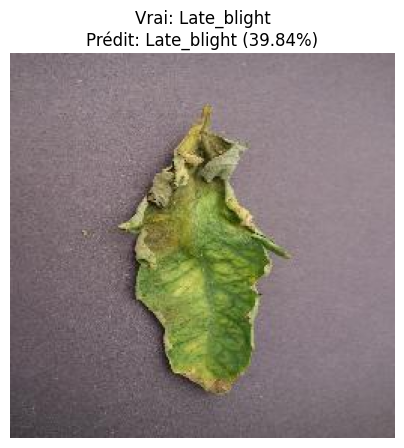

,class,probability
2,Tomato___Late_blight,0.398359
3,Tomato___Leaf_Mold,0.308722
0,Tomato___healthy,0.155423
1,Tomato___Early_blight,0.137496


In [23]:
@torch.no_grad()
def predict_with_dl(model: nn.Module, image_path: Path, image_size: int, device: torch.device):
    model.eval()
    _, eval_transform = make_dl_transforms(image_size)
    image = Image.open(image_path).convert("RGB")
    tensor = eval_transform(image).unsqueeze(0).to(device)
    logits = model(tensor)
    probs = torch.softmax(logits, dim=1).cpu().numpy()[0]
    pred_idx = int(np.argmax(probs))
    return image, probs, pred_idx


sample_test = random.Random(cfg.seed + 999).choice(test_records)
img_vis, probs, pred_idx = predict_with_dl(best_dl_model, sample_test.path, cfg.image_size, device)

plt.figure(figsize=(5, 5))
plt.imshow(img_vis)
plt.title(
    "Vrai: " + sample_test.class_name.replace("Tomato___", "") +
    "\nPrédit: " + TARGET_CLASSES[pred_idx].replace("Tomato___", "") +
    f" ({probs[pred_idx]:.2%})"
)
plt.axis("off")
plt.show()

pd.DataFrame({"class": TARGET_CLASSES, "probability": probs}).sort_values("probability", ascending=False)

## 13) Sauvegarde des résultats

Artefacts légers sauvegardés pour le rapport:
- métriques ML/DL
- tableau comparatif
- poids du meilleur modèle DL

In [24]:
out_ml = OUTPUT_DIR / "ml_metrics.json"
out_dl = OUTPUT_DIR / "dl_metrics.json"
out_cmp = OUTPUT_DIR / "comparison.csv"
out_best = OUTPUT_DIR / "best_dl_model.pt"

with out_ml.open("w", encoding="utf-8") as f:
    json.dump(ml_test_metrics, f, indent=2)

with out_dl.open("w", encoding="utf-8") as f:
    json.dump(
        {
            "scratch": metrics_scratch,
            "transfer": metrics_transfer,
            "best_model": best_dl_name,
        },
        f,
        indent=2,
    )

comparison_df.to_csv(out_cmp, index=False)
torch.save(best_dl_model.state_dict(), out_best)

print("Fichiers sauvegardés:")
for p in [out_ml, out_dl, out_cmp, out_best]:
    print("-", p)

Fichiers sauvegardés:
- C:\plant-desease-igl\artifacts_notebook\ml_metrics.json
- C:\plant-desease-igl\artifacts_notebook\dl_metrics.json
- C:\plant-desease-igl\artifacts_notebook\comparison.csv
- C:\plant-desease-igl\artifacts_notebook\best_dl_model.pt


## 14) Conclusion

Ce notebook implémente l'ensemble du cahier des charges:
- prétraitement + visualisation,
- segmentation/contours + comparaison subjective,
- extraction de caractéristiques dédiée ML,
- entraînement/évaluation de modèles ML,
- extension DL (scratch + transfer learning),
- comparaison finale ML vs DL,
- exemple d'inférence.

Pour un rapport final plus robuste, passer `quick_mode=False` puis relancer toutes les cellules.